In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultimodalNet(nn.Module):
    def __init__(self, structured_input_dim, embedding_input_dim=1536):
        """
        Args:
            structured_input_dim (int): Number of features in your processed structured data 
                                        (e.g., ~23 after OneHotEncoding).
            embedding_input_dim (int): Dimension of your text embeddings (e.g., 768 * 2 = 1536).
        """
        super(MultimodalNet, self).__init__()

        # --- Branch 1: Structured Data Processing ---
        # Theory: The structured input is small. We project it to a hidden layer
        # to let the model learn interactions between features (e.g., Phase + Sponsor).
        self.struct_layer1 = nn.Linear(structured_input_dim, 64)
        self.struct_bn1 = nn.BatchNorm1d(64) # Normalizes data to make training stable
        self.struct_dropout = nn.Dropout(0.3) # Prevents overfitting on metadata

        # --- Branch 2: Text Embedding Processing ---
        # Theory: The embedding input is huge (1536). We need to compress it (Bottleneck)
        # to extract the most relevant semantic signals before merging.
        self.text_layer1 = nn.Linear(embedding_input_dim, 512)
        self.text_bn1 = nn.BatchNorm1d(512)
        self.text_dropout1 = nn.Dropout(0.5) # High dropout because text embeddings are prone to overfitting
        
        self.text_layer2 = nn.Linear(512, 128) # Compress further to 128 features
        self.text_bn2 = nn.BatchNorm1d(128)
        
        # --- Fusion Point ---
        # We will concatenate the 64 structured features + 128 text features.
        # Total combined dimension = 192.
        fusion_dim = 64 + 128
        
        # --- Head: Final Classification ---
        # Theory: The "Manager" looks at the combined view and makes a decision.
        self.fc_final = nn.Linear(fusion_dim, 64)
        self.output = nn.Linear(64, 1) # Output 1 number: The "logit" score for Success

    def forward(self, x_structured, x_text):
        """
        This function defines how data flows through the network.
        """
        
        # 1. Process Structured Data
        out_s = self.struct_layer1(x_structured)
        out_s = self.struct_bn1(out_s)
        out_s = F.relu(out_s) # Apply non-linearity
        out_s = self.struct_dropout(out_s)
        
        # 2. Process Text Data
        out_t = self.text_layer1(x_text)
        out_t = self.text_bn1(out_t)
        out_t = F.relu(out_t)
        out_t = self.text_dropout1(out_t)
        
        out_t = self.text_layer2(out_t)
        out_t = self.text_bn2(out_t)
        out_t = F.relu(out_t)
        # No dropout here, we want strong signals going into fusion
        
        # 3. Fusion (Concatenation)
        # Combine along dimension 1 (columns)
        combined = torch.cat((out_s, out_t), dim=1)
        
        # 4. Final Prediction
        out = self.fc_final(combined)
        out = F.relu(out)
        logits = self.output(out)
        
        # We return "logits" (raw scores), not probabilities. 
        # We will use BCEWithLogitsLoss later, which is mathematically more stable.
        return logits

In [9]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# Import your helper functions
from utils import fit_and_preprocess_train, transform_test_data, ClinicalTrialDataset

# --- 1. Load the P2 Subset (Simulation for Full Data) ---
# Replace with your actual path if different
print("Loading P2 subset...")
df = pd.read_parquet('subset_dataset_with_embeddings.parquet')

# --- 2. Create Train / Validation / Test Splits ---
# We need 3 sets now. Standard approach: 70% Train, 15% Val, 15% Test.
# Stratify is crucial to keep the imbalance consistent across all sets.
X = df  # Features
y = df['overall_status'] # Target for stratification

# Split 1: Separate Test (15%) from the rest (85%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Split 2: Separate Validation (15% of total => ~17.6% of temp) from Train
# 0.15 / 0.85 ≈ 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

# --- 3. Run Preprocessing (The `utils` Pipeline) ---
print("Balancing Training Data...")
# We balance X_train (the raw dataframe)
X_train_balanced = balance_raw_data(X_train)

print("Preprocessing structured data...")
# Note: We pass the BALANCED data to fit_and_preprocess
processed_train_df, rules = fit_and_preprocess_train(X_train_balanced)

# IMPORTANT: Transform Val/Test using rules from the BALANCED set
# This ensures scaling is consistent.
processed_val_df = transform_test_data(X_val, rules)
processed_test_df = transform_test_data(X_test, rules)

# --- 4. Prepare Data for PyTorch (The Tricky Part) ---
# We need to separate Structured features, Embeddings, and Labels into Numpy arrays.

def prepare_arrays(processed_df, raw_df):
    """
    Helper to extract specific components from the dataframes.
    """
    # A. Structured Features
    # Drop target and embedding columns to isolate structured data
    # (Update these column names if your P2 subset uses different ones)
    drop_cols = ['target', 'brief_summary_embedding', 'eligibility_criteria_embedding']
    # Note: processed_df usually doesn't have the embedding columns if utils.py dropped them.
    # But usually utils.py keeps only specific columns. 
    # Let's rely on processed_df structure: it has OneHotEncoded cols + Scaled Numeric + Target.
    
    X_struct = processed_df.drop('target', axis=1).values
    
    # B. Labels
    y = processed_df['target'].values
    
    # C. Embeddings
    # We must grab these from the RAW df (X_train/X_val) because utils.py likely dropped them 
    # or they weren't passed through the scaler.
    # We align them by index.
    raw_aligned = raw_df.loc[processed_df.index]
    
    emb_summary = np.vstack(raw_aligned['brief_summary_embedding'].values)
    emb_criteria = np.vstack(raw_aligned['eligibility_criteria_embedding'].values)
    X_emb = np.concatenate([emb_summary, emb_criteria], axis=1)
    
    return X_struct, X_emb, y

# Generate arrays
print("Converting to Numpy arrays...")
train_struct, train_emb, train_labels = prepare_arrays(processed_train_df, X_train_balanced)
val_struct, val_emb, val_labels = prepare_arrays(processed_val_df, X_val)

# --- 5. Test the ClinicalTrialDataset Class ---
print("Initializing Dataset...")
train_dataset = ClinicalTrialDataset(train_struct, train_emb, train_labels)

# Test __getitem__
sample_struct, sample_emb, sample_label = train_dataset[0]
print(f"\n--- Sanity Check ---")
print(f"Structured Input Shape: {sample_struct.shape}")  # Should be ~23
print(f"Embedding Input Shape: {sample_emb.shape}")   # Should be 1536
print(f"Label: {sample_label}")                       # Should be tensor([0.]) or tensor([1.])

# --- 6. Test the DataLoader (Batching) ---
# This simulates one step of the training loop
loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
batch_struct, batch_emb, batch_labels = next(iter(loader))

print(f"Batch Structured Shape: {batch_struct.shape}") # Should be [32, 23]
print(f"Batch Embedding Shape: {batch_emb.shape}")   # Should be [32, 1536]
print("Test complete. Data pipeline is ready.")

Loading P2 subset...
Train size: 97996, Val size: 21004, Test size: 21000
Balancing Training Data...
Original counts - Success: 53657, Failure: 8771
Balanced counts - Success: 8771, Failure: 8771
Preprocessing structured data...
Dropped 175 rows with missing 'sex' or 'enrollment_count'.
Training data preprocessed successfully according to the specific plan.
Test data transformed successfully using training set rules.
Test data transformed successfully using training set rules.
Converting to Numpy arrays...
Initializing Dataset...

--- Sanity Check ---
Structured Input Shape: torch.Size([23])
Embedding Input Shape: torch.Size([1536])
Label: tensor([1.])
Batch Structured Shape: torch.Size([32, 23])
Batch Embedding Shape: torch.Size([32, 1536])
Test complete. Data pipeline is ready.


## Model Training: The Multimodal Fusion Network

To train our PyTorch model, we define a custom training loop. Unlike high-level libraries (like Scikit-Learn's `.fit()`), PyTorch gives us granular control over every step of the learning process.

### Training Components
1.  **Loss Function (`BCEWithLogitsLoss`):** 
    We use *Binary Cross Entropy with Logits*. This is mathematically more stable than applying a Sigmoid activation followed by a standard BCELoss. It measures how "far away" the model's raw prediction is from the true label (0 or 1).
    
2.  **Optimizer (`Adam`):**
    We use the Adam optimizer, which is an adaptive learning rate optimization algorithm. It is generally faster and more robust than standard Stochastic Gradient Descent (SGD) for complex multimodal landscapes.

3.  **The Loop (Epochs & Batches):**
    *   **Forward Pass:** The data flows through the model to generate a prediction.
    *   **Loss Calculation:** We compute the error between prediction and truth.
    *   **Backward Pass (Backpropagation):** PyTorch calculates the gradients (direction of steepest ascent) for every weight in the network.
    *   **Optimization Step:** The optimizer updates the weights in the opposite direction of the gradient to minimize the error.
    
4.  **Validation Phase:**
    After every epoch (one full pass through the training data), we switch the model to evaluation mode (`model.eval()`) and test it on the unseen Validation Set. This helps us monitor for **overfitting**—if training loss goes down but validation loss goes up, the model is memorizing rather than learning.

In [11]:
# --- 7. Initialize and Train ---

# 1. Create DataLoaders (The Conveyor Belts)
# Batch size 32 or 64 is standard. Drop_last=True ensures we don't have a tiny batch at the end.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Create Validation Dataset & Loader (Using the data we prepared in step 4)
val_dataset = ClinicalTrialDataset(val_struct, val_emb, val_labels)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 2. Initialize the Model
# structured_input_dim MUST be 23 based on your previous output
model = MultimodalNet(structured_input_dim=23, embedding_input_dim=1536)

# 3. Train!
print("Starting training...")
training_history = train_model(model, train_loader, val_loader, num_epochs=5, learning_rate=0.001)

print("Training complete.")

Starting training...
Training on device: cpu
Epoch [1/5] Train Loss: 0.6338 | Val Loss: 0.5920 | Val Acc: 0.6673
Epoch [2/5] Train Loss: 0.6124 | Val Loss: 0.6845 | Val Acc: 0.6149
Epoch [3/5] Train Loss: 0.5983 | Val Loss: 0.6155 | Val Acc: 0.6469
Epoch [4/5] Train Loss: 0.5862 | Val Loss: 0.5857 | Val Acc: 0.6812
Epoch [5/5] Train Loss: 0.5754 | Val Loss: 0.5753 | Val Acc: 0.7035
Training complete.


--- Final Model Performance ---
              precision    recall  f1-score   support

     Failure       0.25      0.57      0.35      1868
     Success       0.91      0.73      0.81     11314

    accuracy                           0.70     13182
   macro avg       0.58      0.65      0.58     13182
weighted avg       0.82      0.70      0.74     13182



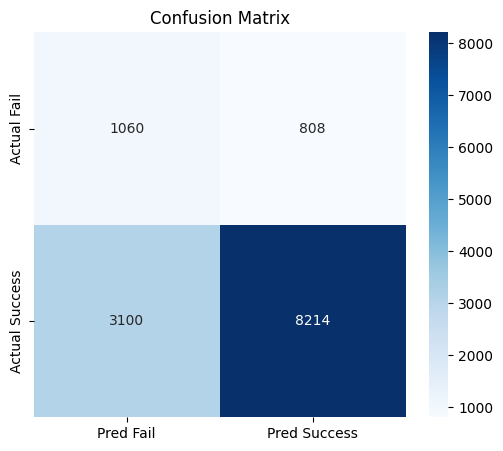

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_performance(model, val_loader):
    """
    Runs the model on the validation set and prints the full metrics.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval() # Safety mode
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_struct, batch_emb, batch_labels in val_loader:
            batch_struct = batch_struct.to(device)
            batch_emb = batch_emb.to(device)
            
            # Get raw scores
            outputs = model(batch_struct, batch_emb)
            
            # Convert to 0 or 1
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            
            # Move back to CPU for sklearn
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())
    
    # Print the report
    print("--- Final Model Performance ---")
    print(classification_report(all_labels, all_preds, target_names=['Failure', 'Success']))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Fail', 'Pred Success'], yticklabels=['Actual Fail', 'Actual Success'])
    plt.title("Confusion Matrix")
    plt.show()

# Run it
evaluate_performance(model, val_loader)